# Importações

In [ ]:
import numpy as np
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pyspark.sql import SparkSession
import pyspark.sql.functions as f
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, MinMaxScaler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier as SkDT

## Funções de ETL

In [ ]:
def executar_sql(sessao_spark, sql):
  return sessao_spark.sql(sql)

def mostrar(df):
  return df.show(truncate=False)

def min_max_coluna(df, coluna):
    resultado = df.select(
        f.min(coluna).alias("minimo"),
        f.max(coluna).alias("maximo")
    ).collect()[0]

    return resultado["minimo"], resultado["maximo"]

def renomear_colunas(df, mapeamento):
    return df.select([
        f.col(c).alias(mapeamento.get(c, c))
        for c in df.columns
    ])

def retornar_linhas_colunas(df):
    linhas = df.count()
    colunas = len(df.columns)

    print((linhas, colunas))

def nulos_por_coluna(df):
    return df.select([
        f.sum(f.col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])

## Funções de ML

In [ ]:
def pipeline_ml_final(df_spark, target_col):
    pdf = df_spark.toPandas()
    features = [c for c in pdf.columns if c not in [target_col, 'qualidade']]
    X = pdf[features]
    y = pdf[target_col]
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X, y)
    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)
    selector = SelectKBest(score_func=f_classif, k=5)
    X_train_red = selector.fit_transform(X_train, y_train)
    X_test_red = selector.transform(X_test)
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_red)
    X_test_scaled = scaler.transform(X_test_red)
    dt = SkDT(max_depth=3, min_samples_leaf=10, random_state=42)
    dt.fit(X_train_red, y_train)
    preds_dt = dt.predict(X_test_red)
    knn = KNeighborsClassifier(n_neighbors=15)
    knn.fit(X_train_scaled, y_train)
    preds_knn = knn.predict(X_test_scaled)
    comparison = pd.DataFrame([
        {"modelo": "Decision Tree", "accuracy": accuracy_score(y_test, preds_dt), "f1_score": f1_score(y_test, preds_dt)},
        {"modelo": "KNN", "accuracy": accuracy_score(y_test, preds_knn), "f1_score": f1_score(y_test, preds_knn)}
    ])
    return {
        "comparison": comparison,
        "y_true": y_test,
        "preds_dt": preds_dt,
        "preds_knn": preds_knn,
        "scaler": scaler,
        "selector": selector,
        "knn_model": knn,
        "feature_names": features
    }

## Funções Gráficas

In [ ]:
def plot_histogramas_grid(df, colunas=None, bins=30, n_colunas=3):

    if colunas is None:
        colunas = [
            campo.name
            for campo in df.schema.fields
            if campo.dataType.typeName() in (
                "integer", "long", "double", "float", "decimal", "short"
            )
        ]

    pdf = df.select(*colunas).toPandas()

    qtd_linhas = math.ceil(len(colunas) / n_colunas)

    fig, axes = plt.subplots(
        nrows=qtd_linhas,
        ncols=n_colunas,
        figsize=(5 * n_colunas, 4 * qtd_linhas)
    )

    axes = axes.flatten()

    for i, coluna in enumerate(colunas):
        axes[i].hist(pdf[coluna].dropna(), bins=bins)
        axes[i].set_title(coluna)

    for i in range(len(colunas), len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()


## Kaggle

In [ ]:
caminho_vinhos = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Caminho para o dataset de vinhos:", caminho_vinhos)

Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
Caminho para o dataset de vinhos: /kaggle/input/wine-quality-dataset


## ETL

In [ ]:
df_vinhos = pd.read_csv(f'{caminho_vinhos}/{os.listdir(caminho_vinhos)[0]}')

In [ ]:
sessao_spark = SparkSession.builder.getOrCreate()

In [ ]:
df_sp_vinhos = sessao_spark.createDataFrame(df_vinhos)

In [ ]:
vw_vinhos = df_sp_vinhos.createOrReplaceTempView("vw_vinhos")

In [ ]:
retornar_linhas_colunas(df_sp_vinhos)

(1143, 13)


## Consultas SQL

In [ ]:
consulta_all = """
SELECT * FROM vw_vinhos
"""

In [ ]:
df_vinhos = executar_sql(sessao_spark, consulta_all)

In [ ]:
mostrar(df_vinhos)

+-------------+----------------+-----------+--------------+------------------+-------------------+--------------------+-------+----+---------+-------+-------+---+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides         |free sulfur dioxide|total sulfur dioxide|density|pH  |sulphates|alcohol|quality|Id |
+-------------+----------------+-----------+--------------+------------------+-------------------+--------------------+-------+----+---------+-------+-------+---+
|7.4          |0.7             |0.0        |1.9           |0.076             |11.0               |34.0                |0.9978 |3.51|0.56     |9.4    |5      |0  |
|7.8          |0.88            |0.0        |2.6           |0.098             |25.0               |67.0                |0.9968 |3.2 |0.68     |9.8    |5      |1  |
|7.8          |0.76            |0.04       |2.3           |0.092             |15.0               |54.0                |0.997  |3.26|0.65     |9.8    |5      |2  |
|11.2         |0.28   

## Verificando o valor mínimo e máximo de cada coluna para ver a necessidade de um escalonador

In [ ]:
df_vinhos = df_vinhos.drop("Id")

In [ ]:
variaveis = {}

for colunas in df_vinhos.columns:
    minimo, maximo = min_max_coluna(df_vinhos, colunas)
    variaveis.update({colunas: [minimo, maximo]})

print(variaveis)

{'fixed acidity': [4.6, 15.9], 'volatile acidity': [0.12, 1.58], 'citric acid': [0.0, 1.0], 'residual sugar': [0.9, 15.5], 'chlorides': [0.012, 0.611], 'free sulfur dioxide': [1.0, 68.0], 'total sulfur dioxide': [6.0, 289.0], 'density': [0.99007, 1.00369], 'pH': [2.74, 4.01], 'sulphates': [0.33, 2.0], 'alcohol': [8.4, 14.9], 'quality': [3, 8]}




> Analisando a diferença entre os valores, é perceptível a necessidade de um standard scaler. O motivo é a divergência de valores numéricos entre cada variável (principalmente total sulfur dioxide - 269)



In [ ]:
novas_colunas = {

    "fixed acidity": "acidez_fixa",
    "volatile acidity": "acidez_volatil",
    "citric acid": "acido_citrico",
    "residual sugar": "acucar_residual",
    "chlorides": "cloridrato",
    "free sulfur dioxide": "dioxido_de_enxofre_livre",
    "total sulfur dioxide": "dioxido_de_enxofre_total",
    "density": "densidade",
    "pH": "pH",
    "sulphates": "sulfatos",
    "alcohol": "alcool",
    "quality": "qualidade"
}

df_vinhos = renomear_colunas(df_vinhos, novas_colunas)

In [ ]:
mostrar(df_vinhos)

+-----------+--------------+-------------+---------------+------------------+------------------------+------------------------+---------+----+--------+------+---------+
|acidez_fixa|acidez_volatil|acido_citrico|acucar_residual|cloridrato        |dioxido_de_enxofre_livre|dioxido_de_enxofre_total|densidade|pH  |sulfatos|alcool|qualidade|
+-----------+--------------+-------------+---------------+------------------+------------------------+------------------------+---------+----+--------+------+---------+
|7.4        |0.7           |0.0          |1.9            |0.076             |11.0                    |34.0                    |0.9978   |3.51|0.56    |9.4   |5        |
|7.8        |0.88          |0.0          |2.6            |0.098             |25.0                    |67.0                    |0.9968   |3.2 |0.68    |9.8   |5        |
|7.8        |0.76          |0.04         |2.3            |0.092             |15.0                    |54.0                    |0.997    |3.26|0.65    |9.8 

## Verificando a distribuição dos dados

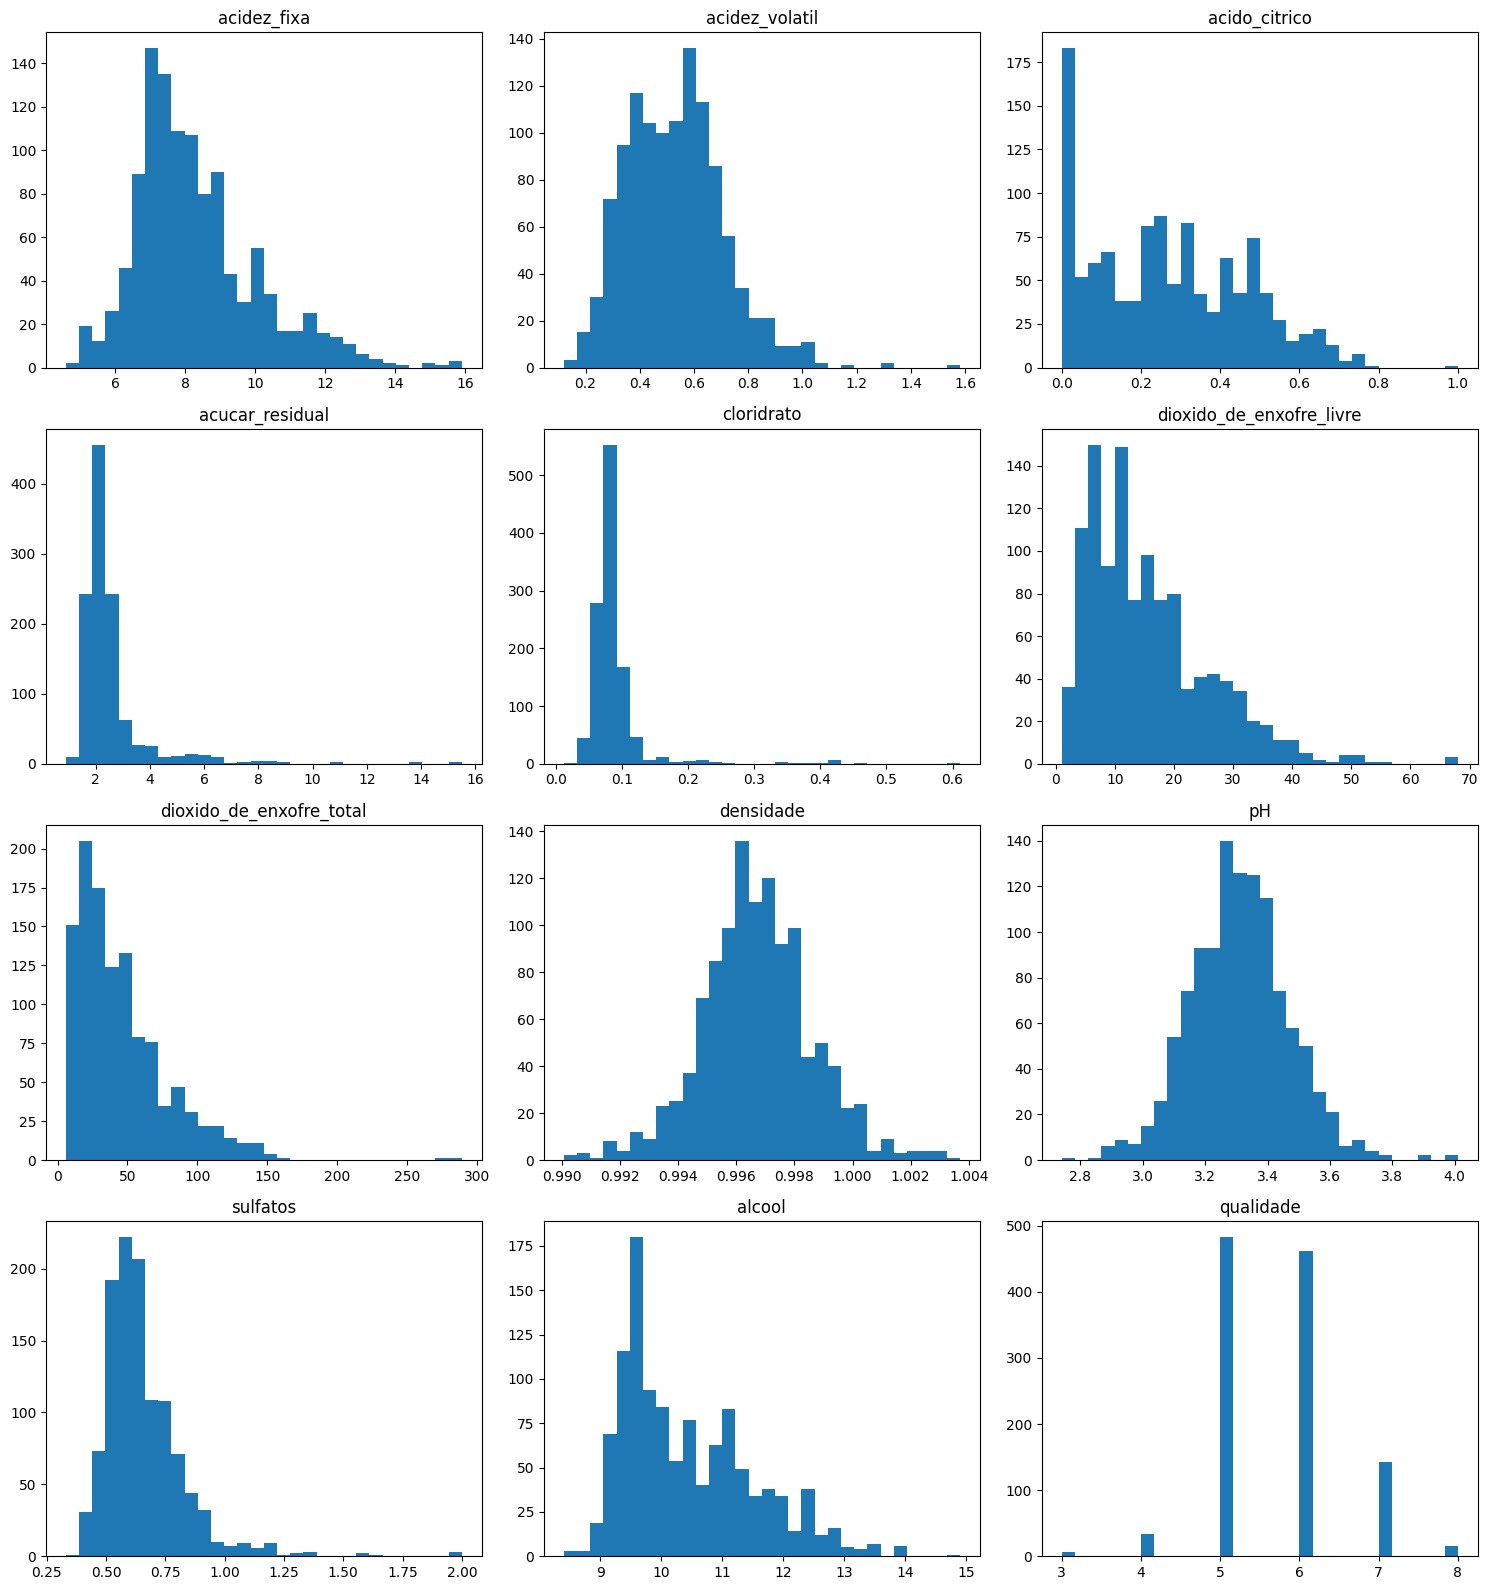

In [ ]:
plot_histogramas_grid(df_vinhos)

> Como podemos ver abaixo, nenhuma das colunas possui valores nulos

In [ ]:
mostrar(nulos_por_coluna(df_vinhos))

+-----------+--------------+-------------+---------------+----------+------------------------+------------------------+---------+---+--------+------+---------+
|acidez_fixa|acidez_volatil|acido_citrico|acucar_residual|cloridrato|dioxido_de_enxofre_livre|dioxido_de_enxofre_total|densidade|pH |sulfatos|alcool|qualidade|
+-----------+--------------+-------------+---------------+----------+------------------------+------------------------+---------+---+--------+------+---------+
|0          |0             |0            |0              |0         |0                       |0                       |0        |0  |0       |0     |0        |
+-----------+--------------+-------------+---------------+----------+------------------------+------------------------+---------+---+--------+------+---------+



In [ ]:
df_vinhos = df_vinhos.withColumn(
    "eh_de_qualidade",
    f.when(f.col("qualidade") >= 7, 1)
     .otherwise(0)
)

### Oversampling (SMOTE) e Preparação de Dados
Como o dataset é pequeno e desbalanceado, utilizaremos o SMOTE para criar amostras sintéticas da classe minoritária, ajudando os modelos a generalizarem melhor.

In [ ]:
# Convertendo para Pandas para facilitar o SMOTE
pdf_vinhos = df_vinhos.toPandas()

features = [c for c in pdf_vinhos.columns if c not in ['qualidade', 'eh_de_qualidade']]
X = pdf_vinhos[features]
y = pdf_vinhos['eh_de_qualidade']

# Aplicando SMOTE para balancear as classes
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(f'Antes do SMOTE: {np.bincount(y)}')
print(f'Depois do SMOTE: {np.bincount(y_res)}')

# Split de Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

Antes do SMOTE: [984 159]
Depois do SMOTE: [984 984]


## Realizando o treino do modelo e extraindo as métricas

---



In [ ]:
# O treino agora é realizado apenas via pipeline_ml_simplificado na célula abaixo.
print('Otimização concluída.')

Otimização concluída.


In [ ]:
res = pipeline_ml_final(df_vinhos, "eh_de_qualidade")
display(res["comparison"])
print("\nRelatório Estatístico - Decision Tree:")
print(classification_report(res["y_true"], res["preds_dt"], target_names=['Comum', 'Premium']))
print("\nRelatório Estatístico - KNN:")
print(classification_report(res["y_true"], res["preds_knn"], target_names=['Comum', 'Premium']))

,modelo,accuracy,f1_score
0,Decision Tree,0.817259,0.834862
1,KNN,0.819797,0.830549



Relatório Estatístico - Decision Tree:
              precision    recall  f1-score   support

       Comum       0.90      0.71      0.80       197
     Premium       0.76      0.92      0.83       197

    accuracy                           0.82       394
   macro avg       0.83      0.82      0.82       394
weighted avg       0.83      0.82      0.82       394


Relatório Estatístico - KNN:
              precision    recall  f1-score   support

       Comum       0.87      0.76      0.81       197
     Premium       0.78      0.88      0.83       197

    accuracy                           0.82       394
   macro avg       0.83      0.82      0.82       394
weighted avg       0.83      0.82      0.82       394



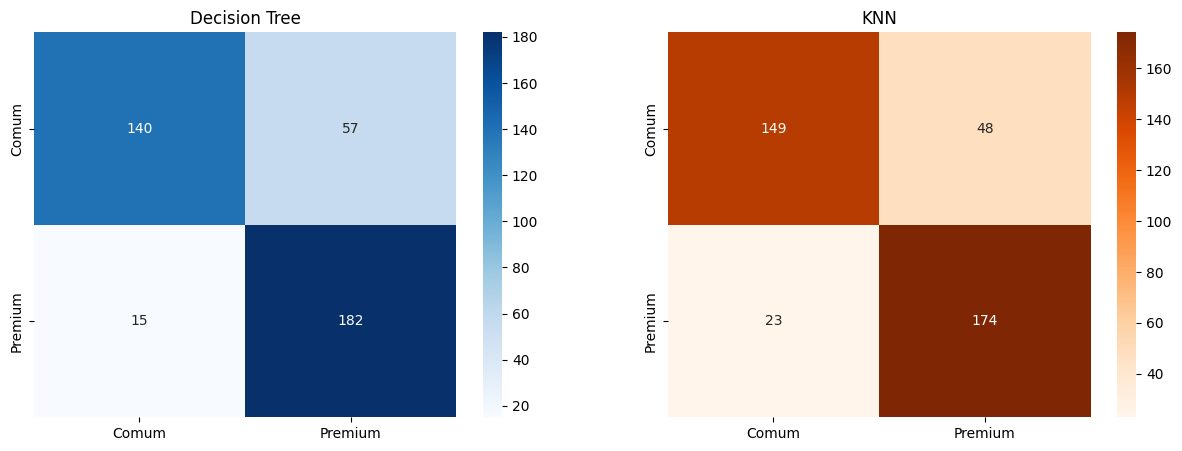

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
labels = ['Comum', 'Premium']
cm_dt = confusion_matrix(res["y_true"], res["preds_dt"])
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=ax[0])
ax[0].set_title("Decision Tree")
cm_knn = confusion_matrix(res["y_true"], res["preds_knn"])
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Oranges", xticklabels=labels, yticklabels=labels, ax=ax[1])
ax[1].set_title("KNN")
plt.show()

### Teste de Previsão
Código para prever se um novo vinho é de qualidade baseado em suas características.

In [ ]:
def realizar_previsao(dados):
    df_input = pd.DataFrame([dados], columns=res["feature_names"])
    input_red = res["selector"].transform(df_input)
    input_scaled = res["scaler"].transform(input_red)
    pred = res["knn_model"].predict(input_scaled)[0]
    prob = res["knn_model"].predict_proba(input_scaled)[0]
    print(f"Veredito: {'Vinho de Qualidade' if pred == 1 else 'Vinho Comum'}")
    print(f"Confianca: {prob[pred]*100:.2f}%")
exemplo = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
realizar_previsao(exemplo)

Veredito: Vinho Comum
Confianca: 100.00%
